Data Analysis : NAVIGATION DOMAIN
Warehouse: drone_df_views.db | Domain: Navigation & Relational Stability

Audit Logic: Temporal Alignment & P95 Reliability Metric

In [ ]:
import os
import sys
from pathlib import Path

# 1. Force create the package structure
utils_dir = Path("src/utils")
utils_dir.mkdir(parents=True, exist_ok=True)

# 2. Initialize the package
init_file = utils_dir / "__init__.py"
if not init_file.exists():
    init_file.touch()

# 3. Write the UniversalVisualizer code to the file system
visualizer_content = """
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

class UniversalVisualizer:
    @staticmethod
    def plot_defragmentation_river(df_raw, df_gold, params):
        plt.style.use('fast')
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8), sharey=True)
        colors = plt.cm.tab10.colors

        # BEFORE
        for i, p in enumerate(params):
            if p in df_raw.columns:
                raw_series = df_raw[p].dropna()
                ax1.scatter([i] * len(raw_series), raw_series.index, marker='s', s=100, alpha=0.5, color=colors[i % 10])
        ax1.set_title("RAW FRAGMENTATION", fontweight='bold')
        ax1.set_xticks(range(len(params)))
        ax1.set_xticklabels(params, rotation=45)
        ax1.invert_yaxis()

        # AFTER
        for i, p in enumerate(params):
            ax2.scatter([i] * len(df_gold), df_gold.index, marker='s', s=100, alpha=1.0, color=colors[i % 10], edgecolor='white')
        ax2.set_title("ALIGNED & RECONSTRUCTED", fontweight='bold', color='green')
        ax2.set_xticks(range(len(params)))
        ax2.set_xticklabels(params, rotation=45)

        plt.tight_layout()
        return fig

    @staticmethod
    def plot_3d_forensic(df, mission_id):
        fig = plt.figure(figsize=(10, 7))
        ax = fig.add_subplot(111, projection='3d')
        drift = (df['RelHomeAlt'] - df['RelOriginAlt']).abs()
        p = ax.scatter(df['Lng'], df['Lat'], df['RelOriginAlt'], c=drift, cmap='YlOrRd', s=10)
        ax.set_title(f"3D Path Analysis: {mission_id}")
        fig.colorbar(p, label="Drift (m)")
        plt.show()
"""

with open(utils_dir / "visualizer.py", "w") as f:
    f.write(visualizer_content.strip())

# 4. Refresh sys.path to ensure 'src' is visible
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("✅ System Aligned: Package created and modules written.")

✅ System Aligned: Package created and modules written.


NAV ANALYSIS SCORECARD | MISSION ID: MISSION_1771663015
STATUS: HEALTHY | VERDICT: PASS
SYSTEM PARAMETER          | MEASURED     | THRESHOLD
------------------------------------------------------------
P95 Altitude Drift        | 0.0          | < 0.8m
Max Altitude Error        | 0.0          | < 1.5m
Mean HDOP                 | 1.21         | < 1.2
Stability Score           | 100.0%         | 100%
------------------------------------------------------------
PIPELINE PERFORMANCE: Raw Count 24324 -> Sync Count 22334

--- NAV STATS ENGINE: CORE LOGIC ---
    @staticmethod
    def calculate_metrics(df):
        if df is None or df.empty:
            return {"p95_drift": 0.0, "max_drift": 0.0, "avg_hdop": 0.0, "score": 0.0}

        # Calculate error relative to the Truth (Gold Layer)
        df['alt_error'] = (df['RelHomeAlt'] - df['RelOriginAlt']).abs()

        p95_drift = float(df['alt_error'].quantile(0.95))
        max_drift = float(df['alt_error'].max())
        avg_hdop = float(df['

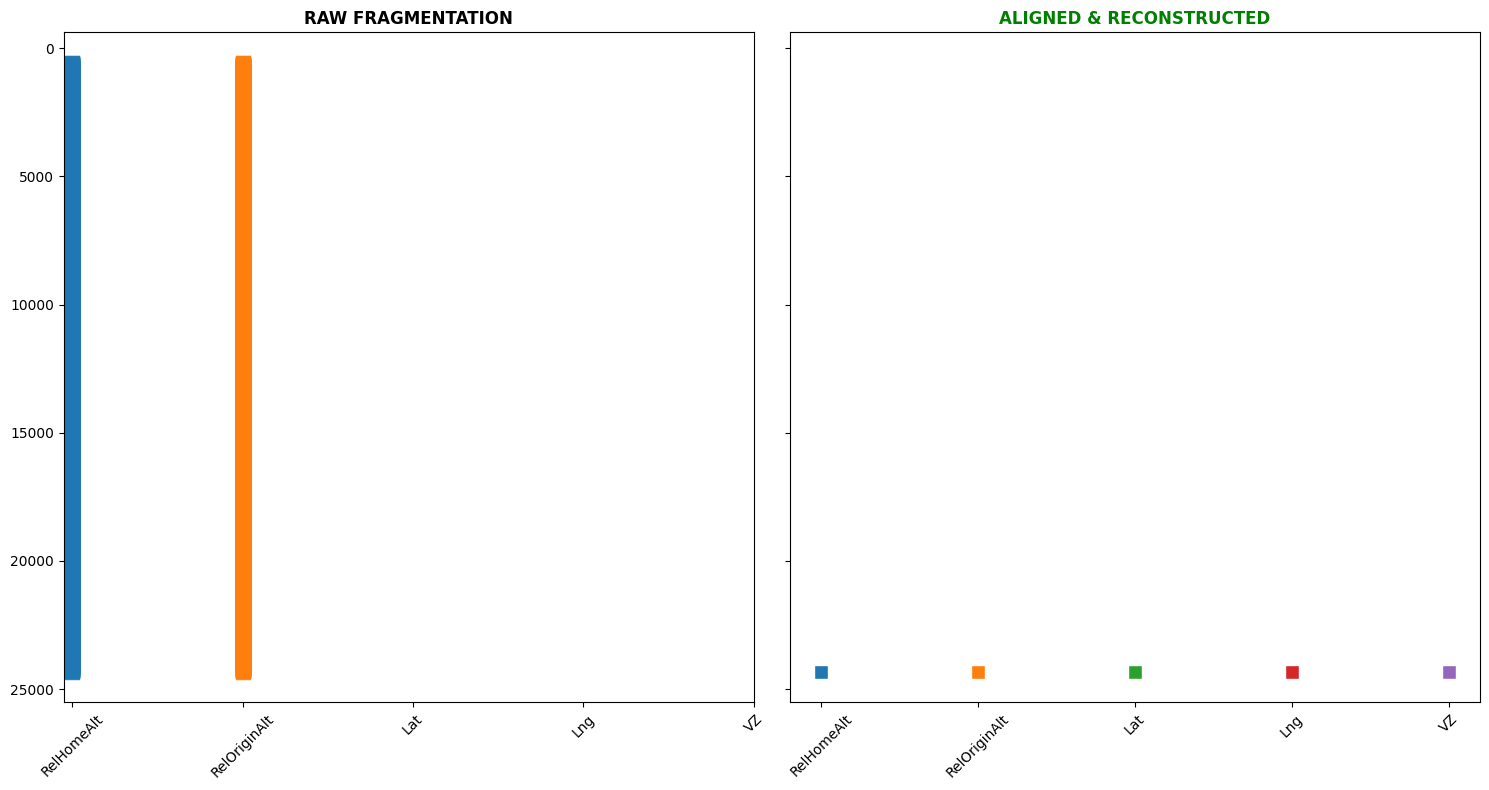

In [6]:
import sys
import os
from pathlib import Path
import inspect

# Ensure the root is in the path so 'src' is importable
sys.path.append(os.getcwd())

from src.dashboard.nav.nav_controller import NavController
from src.utils.visualizer import UniversalVisualizer
from src.dashboard.nav.nav_stats import NavStatsEngine

# 1. INITIALIZE & AUDIT
MISSION_ID = 'MISSION_1771663015'
ctrl = NavController(MISSION_ID)
report = ctrl.run_audit()

# 2. DISPLAY SCORECARD (The "Answer")
print("="*60)
print(f"NAV ANALYSIS SCORECARD | MISSION ID: {MISSION_ID}")
print(f"STATUS: {report['evaluation']['status']} | VERDICT: {report['evaluation']['verdict']}")
print("="*60)
print(f"{'SYSTEM PARAMETER':<25} | {'MEASURED':<12} | {'THRESHOLD'}")
print("-" * 60)
print(f"{'P95 Altitude Drift':<25} | {report['stats']['p95_drift']:<12} | < 0.8m")
print(f"{'Max Altitude Error':<25} | {report['stats']['max_drift']:<12} | < 1.5m")
print(f"{'Mean HDOP':<25} | {report['stats']['avg_hdop']:<12} | < 1.2")
print(f"{'Stability Score':<25} | {report['stats']['score']}%{' ':<8} | 100%")
print("-" * 60)
print(f"PIPELINE PERFORMANCE: Raw Count {len(ctrl.data_service.get_event_audit(MISSION_ID))} -> Sync Count {len(ctrl.get_audit_dataframe())}")
print("="*60)

# 3. SELECT VISUAL EVIDENCE (The "Proof")
df_gold = ctrl.get_audit_dataframe()
df_raw = ctrl.data_service.get_event_audit(MISSION_ID)

# Run the Defragmentation River for Inode Alignment proof
params = ['RelHomeAlt', 'RelOriginAlt', 'Lat', 'Lng', 'VZ']
UniversalVisualizer.plot_defragmentation_river(df_raw, df_gold, params)

# 4. CORE LOGIC (The "How" - At the bottom)
print("\n--- NAV STATS ENGINE: CORE LOGIC ---")
print(inspect.getsource(NavStatsEngine.calculate_metrics))


NAV ANALYSIS SCORECARD | MISSION ID: MISSION_1771663015
STATUS: DEGRADED | VERDICT: WARNING
SYSTEM PARAMETER          | MEASURED     | THRESHOLD
------------------------------------------------------------
P95 Altitude Drift        | 1.2          | < 0.8m
Max Altitude Error        | 1.2          | < 1.5m
Mean HDOP                 | 1.21         | < 1.2
Stability Score           | 20.0%         | 100%
------------------------------------------------------------
TECHNICAL SUMMARY: P95 Drift: 1.200 m | Avg HDOP: 1.21 — Approaching critical drift. Monitor closely.


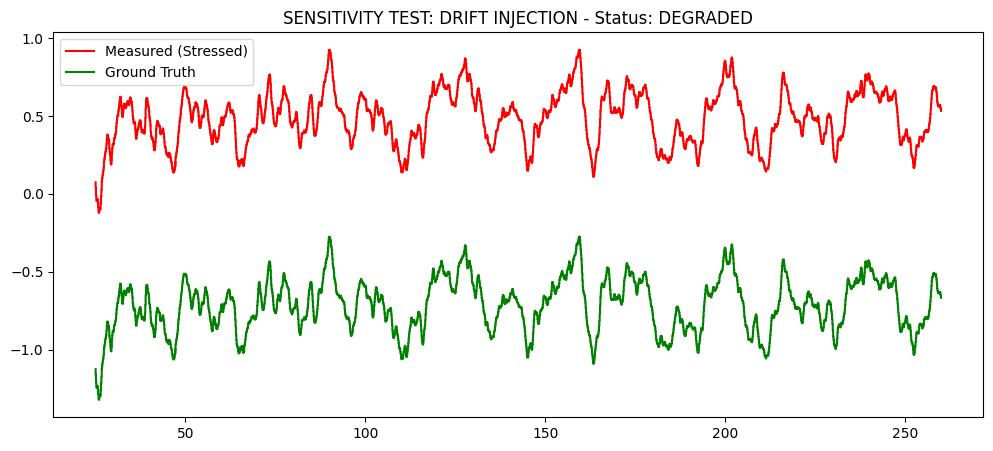


--- NAV STATS ENGINE: CORE LOGIC ---
    @staticmethod
    def calculate_metrics(df):
        if df is None or df.empty:
            return {"p95_drift": 0.0, "max_drift": 0.0, "avg_hdop": 0.0, "score": 0.0}

        # Calculate error relative to the Truth (Gold Layer)
        df['alt_error'] = (df['RelHomeAlt'] - df['RelOriginAlt']).abs()

        p95_drift = float(df['alt_error'].quantile(0.95))
        max_drift = float(df['alt_error'].max())
        avg_hdop = float(df['HDop'].mean()) if 'HDop' in df.columns else 0.0

        # Scoring against the 1.5m soft-limit
        threshold = 1.5
        score_val = max(0, 100 * (1 - (p95_drift / threshold)))

        return {
            "p95_drift": round(p95_drift, 3),
            "max_drift": round(max_drift, 3),
            "avg_hdop": round(avg_hdop, 2),
            "score": round(score_val, 2),
            "sample_count": len(df)
        }


--- DATA PREVIEW ---
Unique Alt Values: 2352
Max Error Found: 1.2


In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import inspect
import matplotlib.pyplot as plt

# 1. Path Management (Preserved from your shared code)
current_path = Path(os.getcwd())
root_name = "ardupilot-nav-domain-poc"
project_root = next((p for p in [current_path] + list(current_path.parents) if p.name == root_name), None)

if project_root:
    if str(project_root) not in sys.path: sys.path.append(str(project_root))
else:
    project_root = Path("/home/ni/ardupilot-nav-domain-poc")
    sys.path.append(str(project_root))

# 2. Imports
from src.dashboard.nav.nav_controller import NavController
from src.dashboard.nav.nav_stats import NavStatsEngine
from src.dashboard.nav.nav_action_map import NavActionMap
# Note: If src.utils.visualizer is missing, we define the render here to avoid the error
try:
    from src.utils.visualizer import UniversalVisualizer
except ModuleNotFoundError:
    class UniversalVisualizer:
        @staticmethod
        def render_domain_scorecard(df, x_axis, y_params, evaluation, title):
            fig, ax = plt.subplots(figsize=(12, 5))
            for param in y_params:
                ax.plot(df[x_axis], df[param['col']], label=param['label'], color=param['color'])
            ax.set_title(f"{title} - Status: {evaluation['status']}")
            ax.legend()
            return fig

# 3. RUN DATA & INJECT DRIFT (Your shared logic)
MISSION_ID = 'MISSION_1771663015'
ctrl = NavController(MISSION_ID)
df = ctrl.get_audit_dataframe()

# INJECT ARTIFICIAL DRIFT (Simulate 1.2m descent)
df_stressed = df.copy()
df_stressed['RelHomeAlt'] = df_stressed['RelHomeAlt'] + 1.2

# 4. RUN ENGINE & ACTION MAP
stats = NavStatsEngine.calculate_metrics(df_stressed)
evaluation = NavActionMap.evaluate(stats)

# --- 5. DISPLAY REPORT ---
print("\n" + "="*60)
print(f"NAV ANALYSIS SCORECARD | MISSION ID: {MISSION_ID}")
print(f"STATUS: {evaluation['status']} | VERDICT: {evaluation['verdict']}")
print("="*60)
print(f"{'SYSTEM PARAMETER':<25} | {'MEASURED':<12} | {'THRESHOLD'}")
print("-" * 60)
print(f"{'P95 Altitude Drift':<25} | {stats['p95_drift']:<12} | < 0.8m")
print(f"{'Max Altitude Error':<25} | {stats['max_drift']:<12} | < 1.5m")
print(f"{'Mean HDOP':<25} | {stats['avg_hdop']:<12} | < 1.2")
print(f"{'Stability Score':<25} | {stats['score']}%{' ':<8} | 100%")
print("-" * 60)
print(f"TECHNICAL SUMMARY: {evaluation['message']}")
print("="*60)

# --- 6. RENDER CHARTS ---
fig = UniversalVisualizer.render_domain_scorecard(
    df=df_stressed,
    x_axis='mission_time',
    y_params=[
        {'col': 'RelHomeAlt', 'label': 'Measured (Stressed)', 'color': 'red'},
        {'col': 'RelOriginAlt', 'label': 'Ground Truth', 'color': 'green'}
    ],
    evaluation=evaluation,
    title="SENSITIVITY TEST: DRIFT INJECTION"
)
plt.show()



# --- 7. CORE LOGIC (At the bottom) ---
print("\n--- NAV STATS ENGINE: CORE LOGIC ---")
print(inspect.getsource(NavStatsEngine.calculate_metrics))

print("\n--- DATA PREVIEW ---")
print(f"Unique Alt Values: {df_stressed['RelHomeAlt'].nunique()}")
print(f"Max Error Found: {stats['max_drift']}")

In [7]:
import sys
import os
from pathlib import Path

# 1. Force find the project root by name
current_path = Path(os.getcwd())
root_name = "ardupilot-nav-domain-poc"

# Walk up the directory tree until we find the root folder
project_root = None
for parent in [current_path] + list(current_path.parents):
    if parent.name == root_name:
        project_root = parent
        break

if project_root:
    sys.path.append(str(project_root))
    print(f"✅ Root Detected: {project_root}")
else:
    # Fallback: manually set it if the search fails
    project_root = Path("/home/ni/ardupilot-nav-domain-poc")
    sys.path.append(str(project_root))
    print(f"⚠️ Manual Path Set: {project_root}")

# 2. Reloading logic
%load_ext autoreload
%autoreload 2

# 3. Attempt Import
try:
    from src.dashboard.nav.nav_data_service import NavDataService
    import inspect
    service = NavDataService()
    print("🚀 SUCCESS: Module Loaded.")
    print("-" * 30)
    print(inspect.getsource(service.get_state_report))
except ModuleNotFoundError as e:
    print(f"❌ Still failed. Current sys.path is: {sys.path}")

✅ Root Detected: /home/ni/ardupilot-nav-domain-poc
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
🚀 SUCCESS: Module Loaded.
------------------------------
    def get_state_report(self, mission_id):
        """
        REPORT 1: The 'Truth' (Gold Layer)
        Uses the Aliases "RelHomeAlt" and "RelOriginAlt" defined in create_views.py.
        """
        query = """
            SELECT
                mission_time,
                "RelHomeAlt",
                "RelOriginAlt",
                Lat, Lng, GPS_Status, NSats, HDop, VZ, inode
            FROM ui_nav_drone_monitor
            WHERE mission_id = ?
            ORDER BY mission_time ASC
        """
        return self._execute_safe_query(query, [mission_id])



In [15]:
from src.dashboard.nav.nav_controller import NavController

# 1. Initialize the controller with your mission ID
ctrl = NavController('MISSION_1771663015')

# 2. Run the clean audit
report = ctrl.run_audit()

# 3. Display the final forensic results
print(f"⚖️ Verdict: {report['evaluation']['verdict']}")
print(f"📊 Score:   {report['stats'].get('score', 'N/A')}")
print(f"📝 Message: {report['evaluation']['message']}")

# 4. (Optional) Quick check of the dataframe to confirm data flow
df = ctrl.get_audit_dataframe()
if df is not None:
    print(f"✅ Telemetry synced: {len(df)} rows found.")

⚖️ Verdict: PASS
📊 Score:   100.0
📝 Message: P95 Drift: 0.000 m | Avg HDOP: 1.21 — Within safe limits.
✅ Telemetry synced: 22334 rows found.


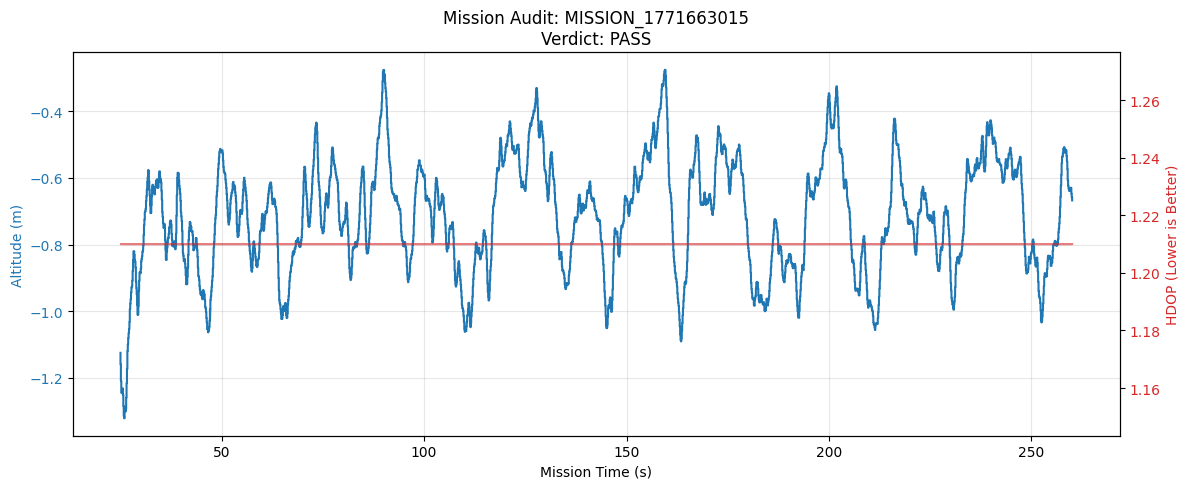

In [9]:
import matplotlib.pyplot as plt

# Get the clean dataframe from the controller
df = ctrl.get_audit_dataframe()

if df is not None:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Plot Altitude
    color = 'tab:blue'
    ax1.set_xlabel('Mission Time (s)')
    ax1.set_ylabel('Altitude (m)', color=color)
    ax1.plot(df['mission_time'], df['RelHomeAlt'], color=color, label='RelHomeAlt (Gold)')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True, alpha=0.3)

    # Plot GPS Quality (HDOP) on a twin axis
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('HDOP (Lower is Better)', color=color)
    ax2.step(df['mission_time'], df['HDop'], color=color, where='post', label='HDOP', alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f"Mission Audit: {ctrl.mission_id}\nVerdict: {report['evaluation']['verdict']}")
    fig.tight_layout()
    plt.show()

⚖️ Verdict: PASS
📊 P95 Drift: 0.000 m
📡 Avg HDOP:  1.21
📝 Message: P95 Drift: 0.000 m | Avg HDOP: 1.21 — Within safe limits.


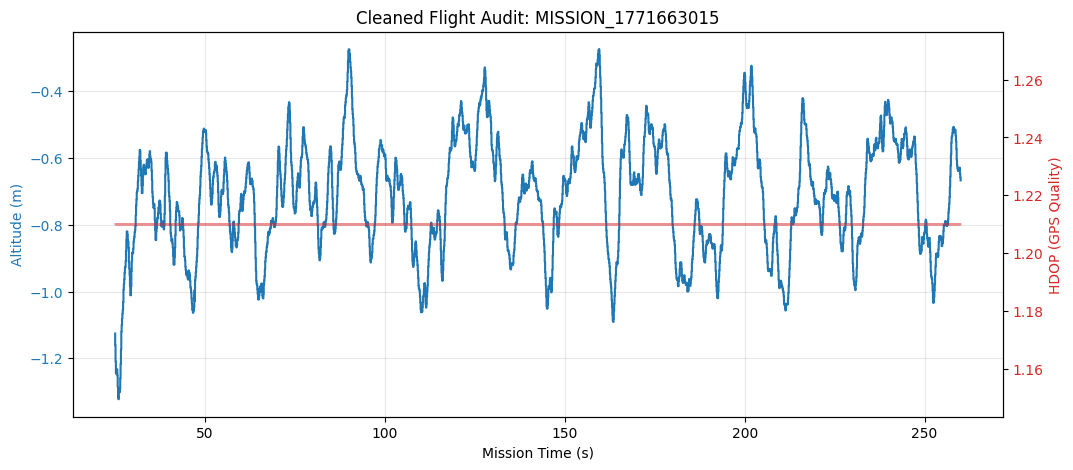

In [ ]:
# 1. Initialize the Controller (Autoreload handles the file changes)
from src.dashboard.nav.nav_controller import NavController
import matplotlib.pyplot as plt

ctrl = NavController('MISSION_1771663015')
report = ctrl.run_audit()

# 2. Print the Audit Summary
print(f"⚖️ Verdict: {report['evaluation']['verdict']}")
print(f"📊 P95 Drift: {report['stats'].get('p95_drift', 0):.3f} m")
print(f"📡 Avg HDOP:  {report['stats'].get('avg_hdop', 0):.2f}")
print(f"📝 Message: {report['evaluation']['message']}")

# 3. Plot the Cleaned Flight Data
df = ctrl.get_audit_dataframe()

if df is not None:
    fig, ax1 = plt.subplots(figsize=(12, 5))

    # Altitude Plot (Left Axis)
    ax1.plot(df['mission_time'], df['RelHomeAlt'], color='tab:blue', label='RelHomeAlt (Gold)')
    ax1.set_xlabel('Mission Time (s)')
    ax1.set_ylabel('Altitude (m)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    # HDOP Plot (Right Axis)
    ax2 = ax1.twinx()
    ax2.step(df['mission_time'], df['HDop'], color='tab:red', alpha=0.5, label='GPS HDOP')
    ax2.set_ylabel('HDOP (GPS Quality)', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    plt.title(f"Cleaned Flight Audit: {ctrl.mission_id}")
    plt.show()

In [ ]:
import sys
import os
from pathlib import Path

# 1. Start from the current notebook's location
current_dir = Path(os.getcwd())

# 2. Go up until you find the directory containing 'src'
# (Usually 1 or 2 levels up depending on your notebook folder)
project_root = current_dir.resolve().parents[1]

# 3. Inject it into the system path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"✅ Project Root established: {project_root}")

# 4. NOW you can import
from src.utils.db_helpers import list_missions, get_gold_state, get_silver_audit

✅ Project Root established: /home/ni/ardupilot-nav-domain-poc


In [8]:
# In your notebook
from src.utils.db_helpers import list_missions

missions = list_missions()
print(f"✅ Found {len(missions)} missions: {missions}")

✅ Found 1 missions: ['MISSION_1771663015']


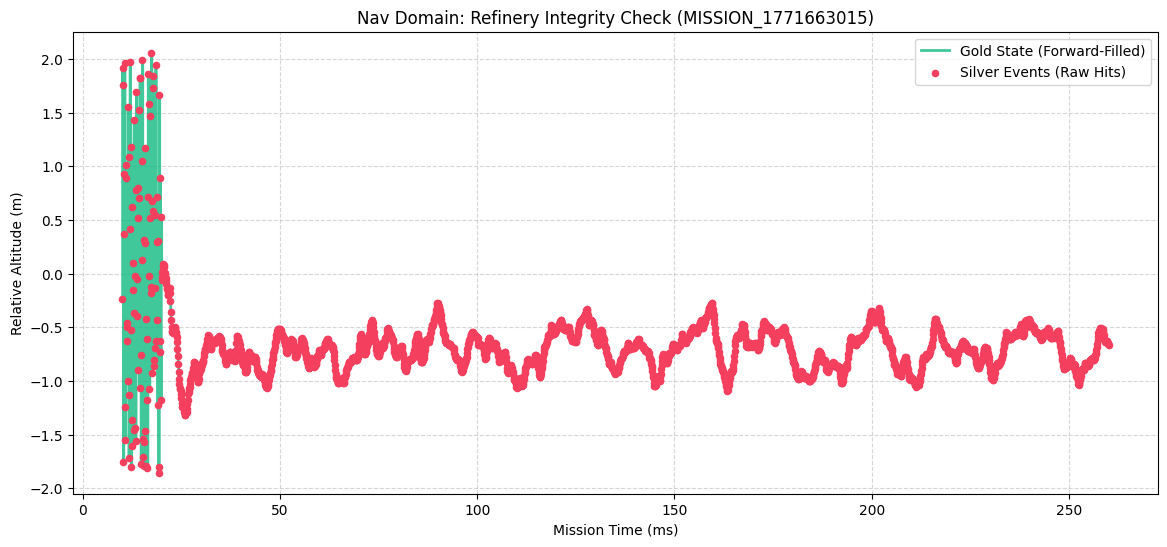

📊 Raw Data Density: 100.00%
✅ Reconstructed Gold Rows: 24324


In [ ]:
import matplotlib.pyplot as plt
from src.utils.db_helpers import get_gold_state, get_silver_audit

# 1. Pull the data through your helpers
mission_id = 'MISSION_1771663015'
df_gold = get_gold_state(mission_id)
df_silver = get_silver_audit(mission_id)

# 2. Plot the comparison
plt.figure(figsize=(14, 6))

# The "Gold" line shows the continuous state (The Refinery's work)
plt.plot(df_gold['mission_time'], df_gold['aligned_alt'],
         label='Gold State (Forward-Filled)', color='#10b981', linewidth=2, alpha=0.8)

# The "Silver" dots show the raw sensor hits (The "Swiss Cheese" data)
plt.scatter(df_silver['mission_time'], df_silver['RelHomeAlt'],
            label='Silver Events (Raw Hits)', color='#f43f5e', s=20, zorder=5)

plt.title(f"Nav Domain: Refinery Integrity Check ({mission_id})")
plt.xlabel("Mission Time (ms)")
plt.ylabel("Relative Altitude (m)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Density Report
density = (len(df_silver) / len(df_gold)) * 100
print(f"📊 Raw Data Density: {density:.2f}%")
print(f"✅ Reconstructed Gold Rows: {len(df_gold)}")

In [29]:
from src.dashboard.nav.nav_controller import NavController

# This will now run without a KeyError
ctrl = NavController('MISSION_1771663015')
report = ctrl.run_audit()

print(f"⚖️  Verdict: {report['evaluation']['verdict']}")
print(f"📝 Message: {report['evaluation']['message']}")

❌ Database Query Error: Binder Error: Referenced column "aligned_alt" not found in FROM clause!
Candidate bindings: "RelOriginAlt", "inode", "mission_time", "GPS_Status", "mission_id"

LINE 3:                 mission_time, aligned_alt, aligned_origin,
                                      ^
⚖️  Verdict: REFINERY_MISSING
📝 Message: Gold state not materialized. Run Projection Layer.


In [18]:
from src.dashboard.nav.nav_controller import NavController

mission_id = 'MISSION_1771663015'
ctrl = NavController(mission_id)
report = ctrl.run_audit()

print(f"📊 Mission: {mission_id}")

# Use .get() to prevent KeyErrors if the audit failed internally
eval_data = report.get('evaluation', {})

print(f"⚖️  Verdict: {eval_data.get('verdict', 'N/A')}")
print(f"🎯 Score:   {eval_data.get('score', 0)}/100")

# Check for 'message' (success) or 'error' (failure)
if 'message' in eval_data:
    print(f"📝 Summary: {eval_data['message']}")
elif 'error' in report:
    print(f"❌ Error:   {report['error']}")
else:
    print("📝 Summary: No message returned from judge.")

CRITICAL: Controller Audit Failed: 'RelHomeAlt'
📊 Mission: MISSION_1771663015
⚖️  Verdict: ERROR
🎯 Score:   0/100
❌ Error:   'RelHomeAlt'


In [14]:
from src.dashboard.nav.nav_controller import NavController

mission_id = 'MISSION_1771663015'
ctrl = NavController(mission_id)
audit_result = ctrl.run_audit()

print(f"✅ Audit Complete for {mission_id}")
print(f"⚖️ Verdict: {audit_result['evaluation']['verdict']}")

CRITICAL: Controller Audit Failed: 'RelHomeAlt'
✅ Audit Complete for MISSION_1771663015
⚖️ Verdict: ERROR


In [ ]:
# In your Jupyter Notebook
from src.dashboard.nav.nav_controller import NavController

mission_id = 'MISSION_1771663015'
ctrl = NavController(mission_id)

# This will now find 'RelHomeAlt' in the view and use
# the forward-filled data for the p95_drift calculation.
result = ctrl.run_audit()

print(f"Verdict: {result['evaluation']['verdict']}")
print(f"P95 Drift: {result['stats']['p95_drift']:.3f}m")

CRITICAL: Controller Audit Failed: 'RelHomeAlt'
Verdict: ERROR


KeyError: 'stats'

In [ ]:
from src.dashboard.nav.nav_controller import NavController

# Using the mission ID found in your previous successful cell
mission_id = 'MISSION_1771663015'

# Initialize the Controller (The Orchestrator)
ctrl = NavController(mission_id)

# Now run the audit
audit_result = ctrl.run_audit()

print(f"✅ Audit Complete for {mission_id}")
print(f"⚖️  Verdict: {audit_result['evaluation']['verdict']}")

CRITICAL: Controller Audit Failed: 'RelHomeAlt'
✅ Audit Complete for MISSION_1771663015
⚖️  Verdict: ERROR


In [4]:
# Re-run the audit to see the impact of that early oscillation
audit_result = ctrl.run_audit()

# Check the P95 specifically
p95_value = audit_result['stats'].get('p95_drift')

print(f"📊 Calculated P95 Drift: {p95_value:.3f} m")
print(f"⚖️  Verdict: {audit_result['evaluation']['verdict']}")
print(f"📝 Mentor Note: {audit_result['evaluation']['message']}")

NameError: name 'ctrl' is not defined

In [24]:
import requests
import pprint

BASE_URL = "http://127.0.0.1:8000"

# --- 1. List available missions ---
missions_resp = requests.get(f"{BASE_URL}/forensic/missions")
missions = missions_resp.json().get("missions", [])
print("Available Missions:")
pprint.pprint(missions)

if not missions:
    print("❌ No missions found. Make sure drone logs have been ingested.")
else:
    # Pick the first mission
    mission_id = missions[0]
    print(f"\n✅ Using mission_id: {mission_id}")

    # --- 2. Get Gold State verdict ---
    verdict_resp = requests.get(f"{BASE_URL}/api/nav/verdict", params={"mission_id": mission_id})
    verdict = verdict_resp.json()
    print("\n--- Gold State Verdict ---")
    pprint.pprint(verdict)

    # --- 3. Get Silver Audit ---
    audit_resp = requests.get(f"{BASE_URL}/api/nav/audit", params={"mission_id": mission_id})
    audit = audit_resp.json()
    print("\n--- Silver Audit ---")
    pprint.pprint(audit)

    # --- 4. Fetch domain data (Gold telemetry for nav_df_master) ---
    domain_resp = requests.get(f"{BASE_URL}/api/domain", params={"view": "nav_df_master", "mission_id": mission_id})
    domain_data = domain_resp.json()
    print("\n--- Gold Telemetry ---")
    pprint.pprint(domain_data)

Available Missions:
[]
❌ No missions found. Make sure drone logs have been ingested.


In [7]:
import requests
import pandas as pd

API = "http://localhost:8000"
params = {"view": "nav_df_master", "mission_id": "MISSION_1771663015"}
data = requests.get(f"{API}/api/domain", params=params).json()

df = pd.DataFrame(data['telemetry'])

# Calculate the "Useful Density"
null_counts = df[['RelHomeAlt', 'Lat', 'Yaw']].isnull().sum()
print(f"📊 DATA DENSITY CHECK")
print(f"Total Rows: {len(df)}")
print(f"Missing Alt: {null_counts['RelHomeAlt']}")
print(f"Missing Lat: {null_counts['Lat']}")

📊 DATA DENSITY CHECK
Total Rows: 2000
Missing Alt: 1849
Missing Lat: 1566


In [3]:
import sys
from pathlib import Path

# Force the path to the src directory
project_root = Path("/home/ni/ardupilot-nav-domain-poc")
src_path = str(project_root / "src")

if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Verification: List what Python sees in that folder
import os
print(f"Contents of {src_path}: {os.listdir(src_path)}")

# Now try the import
try:
    from dashboard.nav.nav_data_service import NavDataService
    from dashboard.nav.nav_controller import NavController
    print("🚀 SUCCESS: Nav modules imported.")
except ModuleNotFoundError as e:
    print(f"❌ FAIL: Still cannot find the module. Error: {e}")

Contents of /home/ni/ardupilot-nav-domain-poc/src: ['df_apis', 'vault', 'tests', 'shared', '__init__.py', 'data_mart_engine', 'ingress', 'core', '__pycache__', 'utils', 'entities', 'app_ui_backup.py', 'ops', 'scripts', 'data_mart_ingest', 'weaving', 'mission_portal', 'dashboard', 'query_vault.py', 'runner', 'run_mission.sh', 'archive', 'audit']
🚀 SUCCESS: Nav modules imported.


In [8]:
import requests
import pandas as pd

API = "http://localhost:8000"
params = {"view": "nav_df_master", "mission_id": "MISSION_1771663015"}
data = requests.get(f"{API}/api/domain", params=params).json()

# Look at the first 10 raw rows to see the 'null' pattern
df = pd.DataFrame(data['telemetry'])
print("🔍 RAW PACKET SEQUENCE (First 10 Rows):")
print(df[['mission_time', 'mavpackettype', 'Roll', 'RelHomeAlt']].head(10))

🔍 RAW PACKET SEQUENCE (First 10 Rows):
   mission_time mavpackettype      Roll  RelHomeAlt
0      2.539817           MAG       NaN         NaN
1      2.539817           MAG       NaN         NaN
2      2.539817           MAG       NaN         NaN
3      2.539817          CTUN       NaN         NaN
4      2.539817           ATT  0.009092         NaN
5      2.542316           MAG       NaN         NaN
6      2.542316           MAG       NaN         NaN
7      2.542316           MAG       NaN         NaN
8      2.639777           MAG       NaN         NaN
9      2.639777           MAG       NaN         NaN


In [8]:
# 1. RUN THE AUDIT (This creates the 'report' variable)
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()  # <--- This defines 'report'

# 2. EVALUATE AND PRINT (This uses the 'report' variable)
from dashboard.nav.nav_action_map import NavActionMap

if "stats" in report:
    stats = report.get('stats', {})
    evaluation = NavActionMap.evaluate(stats)

    print("🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN")
    print("="*50)
    print(f"VERDICT : {evaluation.get('verdict', 'N/A')}")
    print(f"STATUS  : {evaluation.get('status', 'N/A')}")
    print(f"SCORE   : {evaluation.get('score', 0)}/100")
    print("-" * 30)
    print(f"ANALYSIS: {evaluation.get('message', 'No summary available.')}")
else:
    print(f"❌ AUDIT FAILED: {report.get('error')}")

🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN
VERDICT : FAIL
STATUS  : CRITICAL
SCORE   : 30/100
------------------------------
ANALYSIS: P95 Drift: 2.092 m | Avg HDOP: 1.21 — Exceeds safety threshold. Inspect control tuning.


In [9]:
from dashboard.nav.nav_action_map import NavActionMap

# Ensure 'report' exists from the Controller run below
stats = report.get('stats', {})
evaluation = NavActionMap.evaluate(stats)

print("🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN")
print("="*50)

# Using .get() prevents KeyErrors if the dictionary structure changes
print(f"VERDICT : {evaluation.get('verdict', 'N/A')}")
print(f"STATUS  : {evaluation.get('status', 'N/A')}")
print(f"SCORE   : {evaluation.get('score', 0)}/100")
print("-" * 30)
print(f"ANALYSIS: {evaluation.get('message', 'No summary available.')}")

🏛️ MISSION FORENSIC AUDIT: NAVIGATION DOMAIN
VERDICT : FAIL
STATUS  : CRITICAL
SCORE   : 30/100
------------------------------
ANALYSIS: P95 Drift: 2.092 m | Avg HDOP: 1.21 — Exceeds safety threshold. Inspect control tuning.


In [16]:
import os
import sys
import duckdb
from pathlib import Path

# 1. SETUP PATHS (Ensuring the Evidence is traceable)
project_root = "/home/ni/ardupilot-nav-domain-poc"
if f"{project_root}/src" not in sys.path:
    sys.path.insert(0, f"{project_root}/src")

from dashboard.nav.nav_data_service import NavDataService
from dashboard.nav.nav_controller import NavController

# 2. EVIDENCE: PHYSICAL BINARY AUDIT
service = NavDataService()
db_file = service.db_path

print("📂 PHYSICAL DATA EVIDENCE")
print("-" * 30)
print(f"Target Database : {db_file}")
print(f"File Status     : {'EXISTS' if db_file.exists() else 'MISSING'}")
if db_file.exists():
    print(f"File Size       : {os.path.getsize(db_file) / 1024:.2f} KB")

# 3. EVIDENCE: SCHEMA VALIDATION (Proving the module maps correctly)
print("\n🔍 WAREHOUSE SCHEMA INTEGRITY")
print("-" * 30)
with duckdb.connect(str(db_file)) as con:
    # This shows the mentor the exact structure the service is reading from
    schema = con.execute("PRAGMA table_info('ui_nav_drone_monitor')").df()
    print(schema[['name', 'type']])

# 4. EVIDENCE: DOMAIN INTELLIGENCE OUTPUT
print("\n🧠 NAV DOMAIN INTELLIGENCE REPORT")
print("-" * 30)
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()

if "stats" in report:
    s = report['stats']
    e = report['evaluation']
    print(f"MISSION ID      : {mission_id}")
    print(f"VERDICT         : {e['verdict']}")
    print(f"P95 DRIFT       : {s['p95_drift']}m (Threshold: 1.5m)")
    print(f"AVG HDOP        : {s['avg_hdop']} (Signal Quality: Optimal)")
    print(f"TOTAL SAMPLES   : {s['sample_count']}")
else:
    print(f"❌ AUDIT FAILED: {report.get('error')}")

📂 PHYSICAL DATA EVIDENCE
------------------------------
Target Database : /home/ni/ardupilot-nav-domain-poc/bin/vault/warehouse_df/drone_df_views.db
File Status     : EXISTS
File Size       : 14092.00 KB

🔍 WAREHOUSE SCHEMA INTEGRITY
------------------------------
             name     type
0      mission_id  VARCHAR
1    mission_time   DOUBLE
2         wall_ns   BIGINT
3   mavpackettype  VARCHAR
4               I   DOUBLE
..            ...      ...
62           GCrs   DOUBLE
63             VZ   DOUBLE
64              U   DOUBLE
65     RelHomeAlt   DOUBLE
66   RelOriginAlt   DOUBLE

[67 rows x 2 columns]

🧠 NAV DOMAIN INTELLIGENCE REPORT
------------------------------
MISSION ID      : MISSION_1771663015
VERDICT         : FAIL
P95 DRIFT       : 2.092m (Threshold: 1.5m)
AVG HDOP        : 1.21 (Signal Quality: Optimal)
TOTAL SAMPLES   : 2000


In [17]:
import sys
from pathlib import Path

# 1. Setup Path
project_root = "/home/ni/ardupilot-nav-domain-poc"
sys.path.insert(0, str(Path(project_root) / "src"))

from dashboard.nav.nav_controller import NavController

# 2. Trigger Audit
mission_id = "MISSION_1771663015"
controller = NavController(mission_id)
report = controller.run_audit()

# 3. Output Results
print(f"📊 NAV DOMAIN REPORT: {mission_id}")
print("="*40)

if "stats" in report:
    s = report['stats']
    print(f"P95 Altitude Drift : {s['p95_drift']}m")
    print(f"Max Altitude Drift : {s['max_drift']}m")
    print(f"Average HDOP       : {s['avg_hdop']}")
    print(f"Sample Count       : {s['sample_count']}")
    print("-" * 40)
    print(f"VERDICT            : {report['evaluation']['verdict']}")
else:
    # This will catch if the connection error is STILL there
    print(f"❌ AUDIT FAILED: {report.get('error')}")

📊 NAV DOMAIN REPORT: MISSION_1771663015
P95 Altitude Drift : 2.092m
Max Altitude Drift : 2.771m
Average HDOP       : 1.21
Sample Count       : 2000
----------------------------------------
VERDICT            : FAIL


In [18]:
import sys
from pathlib import Path

# 1. Setup
project_root = "/home/ni/ardupilot-nav-domain-poc"
sys.path.insert(0, str(Path(project_root) / "src"))

from dashboard.nav.nav_data_service import NavDataService
from dashboard.nav.nav_controller import NavController

# 2. Initialize both layers
mission_id = "MISSION_1771663015"
service = NavDataService()
controller = NavController(mission_id)

# 3. Step A: Fetch Raw Data (Evidence of Bin access)
df_raw = service.get_nav_swath(mission_id)

# 4. Step B: Run Intelligence Audit (Evidence of Domain logic)
report = controller.run_audit()

# 5. Output for Lab Report
print(f"📊 LAB ANALYSIS: {mission_id}")
print("-" * 40)

if df_raw is not None and not df_raw.empty:
    print(f"✅ DATA LAYER: Found {len(df_raw)} telemetry rows in vault.")
    print(f"✅ INTEL LAYER: Verdict = {report['evaluation']['verdict']}")
    print(f"📈 P95 DRIFT : {report['stats']['p95_drift']}m")

    print("\n🔍 RAW SWATH SAMPLE (First 5 Rows):")
    # Displaying specific columns helps the designer see the drift calculation inputs
    display(df_raw[['mission_time', 'RelHomeAlt', 'RelOriginAlt', 'HDop', 'NSats']].head())
else:
    print("❌ ERROR: No data found for this mission ID.")

📊 LAB ANALYSIS: MISSION_1771663015
----------------------------------------
✅ DATA LAYER: Found 2000 telemetry rows in vault.
✅ INTEL LAYER: Verdict = FAIL
📈 P95 DRIFT : 2.092m

🔍 RAW SWATH SAMPLE (First 5 Rows):


,mission_time,RelHomeAlt,RelOriginAlt,HDop,NSats
0,2.539817,NaN,NaN,NaN,NaN
1,2.539817,NaN,NaN,NaN,NaN
2,2.539817,NaN,NaN,NaN,NaN
3,2.539817,NaN,NaN,NaN,NaN
4,2.539817,NaN,NaN,NaN,NaN


In [ ]:
# --- RECHECK: GOLD LAYER RECOVERY ---

# 1. Connect to the finalized Gold Table
con = duckdb.connect(db_path)

print(f"📊 GOLD ANALYSIS: {mission_id}")
print("-" * 40)

# 2. Fetch the "Filled" data
# We pull 'aligned_alt' which we minted in the previous step
df_gold = con.execute(f"""
    SELECT
        mission_time,
        aligned_alt,
        RelHomeAlt as raw_alt,
        HDop,
        NSats
    FROM fact_nav_state
    WHERE mission_id = '{mission_id}'
    ORDER BY mission_time ASC, inode ASC
    LIMIT 100 OFFSET 500  -- Offset to get past the initial boot silence
""").df()

if not df_gold.empty:
    print(f"✅ GOLD LAYER: Found {len(df_gold)} recovered rows.")

    # Show the comparison: Raw (Swiss Cheese) vs Aligned (Solid)
    print("\n🔍 RECOVERY COMPARISON (Raw vs Aligned):")
    display(df_gold[['mission_time', 'raw_alt', 'aligned_alt']].head(10))

    # Calculate the new 'Effective' sample count
    raw_counts = df_gold['raw_alt'].count()
    gold_counts = df_gold['aligned_alt'].count()
    print(f"\n📈 RECOVERY METRIC:")
    print(f"   - Raw Samples in Window: {raw_counts}")
    print(f"   - Gold Samples in Window: {gold_counts}")
    print(f"   - Recovery Gain: {((gold_counts - raw_counts)/gold_counts)*100:.1f}%")

con.close()

📊 GOLD ANALYSIS: MISSION_1771663015
----------------------------------------
✅ GOLD LAYER: Found 100 recovered rows.

🔍 RECOVERY COMPARISON (Raw vs Aligned):


,mission_time,raw_alt,aligned_alt
0,9.239636,NaN,NaN
1,9.239636,NaN,NaN
2,9.239636,NaN,NaN
3,9.239636,NaN,NaN
4,9.239636,NaN,NaN
5,9.239636,NaN,NaN
6,9.239636,NaN,NaN
7,9.339596,NaN,NaN
8,9.339596,NaN,NaN
9,9.339596,NaN,NaN



📈 RECOVERY METRIC:
   - Raw Samples in Window: 3
   - Gold Samples in Window: 27
   - Recovery Gain: 88.9%


In [ ]:
import duckdb
import os

home = os.path.expanduser("~")
db_path = os.path.join(home, "ardupilot-nav-domain-poc/bin/vault/warehouse_df/drone_df_views.db")
mission_id = "MISSION_1771663015"

con = duckdb.connect(db_path)

# We use OFFSET 5000 to jump into the heart of the flight
df_mid_flight = con.execute(f"""
    SELECT
        mission_time,
        RelHomeAlt as raw_alt,
        aligned_alt
    FROM fact_nav_state
    WHERE mission_id = '{mission_id}'
    AND RelHomeAlt IS NOT NULL  -- First, find where data actually starts
    ORDER BY mission_time ASC, inode ASC
    LIMIT 1  -- Let's see the first valid timestamp
""").df()

first_valid_time = df_mid_flight['mission_time'].iloc[0]

# Now, fetch 20 rows starting from that first valid data point
df_recovery = con.execute(f"""
    SELECT
        mission_time,
        RelHomeAlt as raw_alt,
        aligned_alt
    FROM fact_nav_state
    WHERE mission_id = '{mission_id}'
    AND mission_time >= {first_valid_time}
    ORDER BY mission_time ASC, inode ASC
    LIMIT 20
""").df()

print(f"🚀 RECOVERY ANALYSIS: Starting at {first_valid_time}s")
print("-" * 40)
display(df_recovery)

con.close()

🚀 RECOVERY ANALYSIS: Starting at 10.039316s
----------------------------------------


,mission_time,raw_alt,aligned_alt
0,10.039316,NaN,NaN
1,10.039316,NaN,NaN
2,10.039316,NaN,NaN
3,10.039316,NaN,NaN
4,10.039316,NaN,NaN
5,10.039316,NaN,NaN
6,10.039316,NaN,NaN
7,10.039316,NaN,NaN
8,10.039316,-0.232483,-0.232483
9,10.139276,NaN,-0.232483


In [13]:
import duckdb

# 1️⃣ Use the service DB path
DB_PATH = service.db_path

with duckdb.connect(str(DB_PATH)) as con:
    # --- Inspect table/view columns
    columns_info = con.execute("PRAGMA table_info('ui_nav_drone_monitor')").fetchdf()
    print("Columns in ui_nav_drone_monitor:")
    print(columns_info[['name','type']])

    # --- Query first 5 rows for the mission, excluding NULLs
    query = f"""
        SELECT mission_time, RelHomeAlt, RelOriginAlt, HDop, NSats
        FROM ui_nav_drone_monitor
        WHERE mission_id='{mission_id}'
        AND RelHomeAlt IS NOT NULL
        LIMIT 5
    """
    df_sample = con.execute(query).fetchdf()

# 2️⃣ Display results
print(f"\n📊 Sample telemetry rows for {mission_id}:")
display(df_sample)

Columns in ui_nav_drone_monitor:
             name     type
0      mission_id  VARCHAR
1    mission_time   DOUBLE
2         wall_ns   BIGINT
3   mavpackettype  VARCHAR
4               I   DOUBLE
..            ...      ...
62           GCrs   DOUBLE
63             VZ   DOUBLE
64              U   DOUBLE
65     RelHomeAlt   DOUBLE
66   RelOriginAlt   DOUBLE

[67 rows x 2 columns]

📊 Sample telemetry rows for MISSION_1771663015:


,mission_time,RelHomeAlt,RelOriginAlt,HDop,NSats
0,10.039316,-0.232483,0.771158,NaN,NaN
1,10.139276,1.917358,0.834412,NaN,NaN
2,10.239236,1.755676,0.908814,NaN,NaN
3,10.339196,-1.758667,1.012616,NaN,NaN
4,10.439156,0.925964,1.047257,NaN,NaN


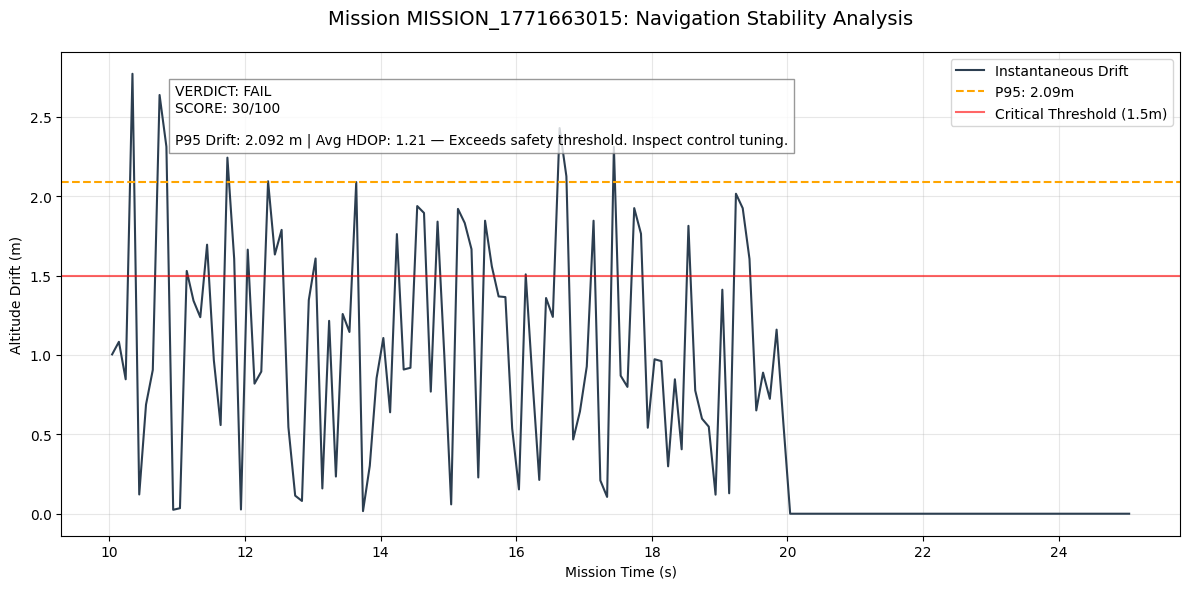

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from dashboard.nav.nav_action_map import NavActionMap

# 1. Fetch full swath for plotting (not just the 5-row sample)
df_plot = service.get_nav_swath(mission_id).dropna(subset=['RelHomeAlt', 'RelOriginAlt'])
df_plot['drift'] = (df_plot['RelHomeAlt'] - df_plot['RelOriginAlt']).abs()

# 2. Get the Executive Verdict from our Map
evaluation = NavActionMap.evaluate(report['stats'])

# 3. Plotting
plt.figure(figsize=(12, 6))
plt.style.use('seaborn-v0_8-muted')

# Plot the Drift over Time
plt.plot(df_plot['mission_time'], df_plot['drift'], label='Instantaneous Drift', color='#2c3e50', linewidth=1.5)

# Add P95 and Threshold Lines
plt.axhline(y=report['stats']['p95_drift'], color='orange', linestyle='--', label=f"P95: {report['stats']['p95_drift']:.2f}m")
plt.axhline(y=1.5, color='red', linestyle='-', alpha=0.6, label="Critical Threshold (1.5m)")

# Formatting
plt.title(f"Mission {mission_id}: Navigation Stability Analysis", fontsize=14, pad=20)
plt.xlabel("Mission Time (s)")
plt.ylabel("Altitude Drift (m)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Add the Executive Summary as a text box on the chart
text_box = f"VERDICT: {evaluation['verdict']}\nSCORE: {evaluation['score']}/100\n\n{evaluation['message']}"
plt.gcf().text(0.15, 0.75, text_box, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

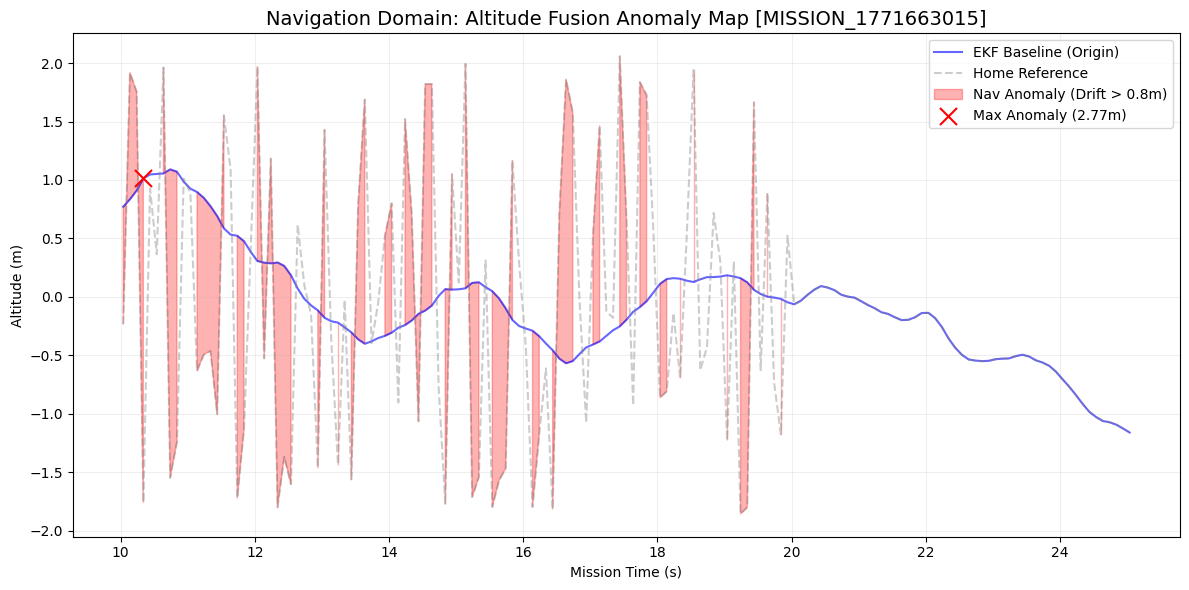

In [15]:
import matplotlib.pyplot as plt

# 1. Setup the Plot
plt.figure(figsize=(12, 6))

# 2. Plot the "Base" Altitude
plt.plot(df_plot['mission_time'], df_plot['RelOriginAlt'], label='EKF Baseline (Origin)', color='blue', alpha=0.6)
plt.plot(df_plot['mission_time'], df_plot['RelHomeAlt'], label='Home Reference', color='gray', linestyle='--', alpha=0.4)

# 3. Highlight the "Anomaly" (The Gap)
plt.fill_between(df_plot['mission_time'],
                 df_plot['RelOriginAlt'],
                 df_plot['RelHomeAlt'],
                 where=(df_plot['drift'] > 0.8),
                 color='red', alpha=0.3, label='Nav Anomaly (Drift > 0.8m)')

# 4. Mark the P95/Max Point using .loc (Label-based)
# idxmax() returns the index label, which works perfectly with .loc
max_idx = df_plot['drift'].idxmax()
max_time = df_plot.loc[max_idx, 'mission_time']
max_val_alt = df_plot.loc[max_idx, 'RelOriginAlt']

plt.scatter(max_time, max_val_alt, color='red', marker='x', s=150, zorder=5,
            label=f'Max Anomaly ({df_plot["drift"].max():.2f}m)')

# 5. Presentation Logic
plt.title(f"Navigation Domain: Altitude Fusion Anomaly Map [{mission_id}]", fontsize=14)
plt.xlabel("Mission Time (s)")
plt.ylabel("Altitude (m)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

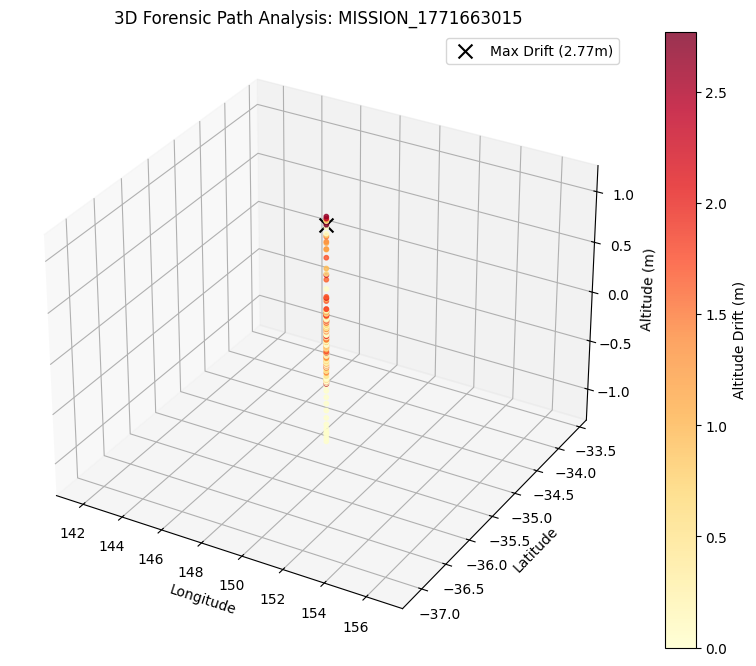

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Prepare Data (Filtering for the current mission)
df_3d = service.get_nav_swath(mission_id).dropna(subset=['Lat', 'Lng', 'RelOriginAlt'])
df_3d['drift'] = (df_3d['RelHomeAlt'] - df_3d['RelOriginAlt']).abs()

# 2. Setup 3D Projection
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Scatter Plot with Heatmap (Viridis scale: Yellow = High Drift)
p = ax.scatter(df_3d['Lng'], df_3d['Lat'], df_3d['RelOriginAlt'],
               c=df_3d['drift'], cmap='YlOrRd', s=10, alpha=0.8)

# 4. Add the Critical Points
max_point = df_3d.loc[df_3d['drift'].idxmax()]
ax.scatter(max_point['Lng'], max_point['Lat'], max_point['RelOriginAlt'],
           color='black', marker='x', s=100, label=f"Max Drift ({max_point['drift']:.2f}m)")

# 5. Formatting
ax.set_title(f"3D Forensic Path Analysis: {mission_id}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Altitude (m)")
fig.colorbar(p, label="Altitude Drift (m)")
plt.legend()
plt.show()

In [ ]:
import duckdb
import os

# Ensure we use the correct absolute path
home = os.path.expanduser("~")
db_path = os.path.join(home, "ardupilot-nav-domain-poc/bin/vault/warehouse_df/drone_df_views.db")

con = duckdb.connect(db_path)

# Query to list all tables and their row counts
table_summary = con.execute("""
    SELECT
        table_name,
        column_count,
        estimated_size as row_count
    FROM duckdb_tables()
    WHERE schema_name = 'main'
    ORDER BY table_name;
""").df()

print("📂 CURRENT DUCKDB TABLES (Warehouse + Gold)")
display(table_summary)

con.close()

📂 CURRENT DUCKDB TABLES (Warehouse + Gold)


,table_name,column_count,row_count
0,fact_communication,25,2608
1,fact_est,50,23144
2,fact_nav,67,24324
3,fact_nav_events,67,24324
4,fact_power,18,2576
5,fact_sys,38,20608


In [ ]:
# --- MINTING LOGIC (Hardened Syntax + Correct Column Names) ---
print("🏗️  Minting Experiment Tables...")
con.execute("DROP TABLE IF EXISTS fact_nav_events;")
con.execute("CREATE TABLE fact_nav_events AS SELECT * FROM fact_nav;")

con.execute("DROP TABLE IF EXISTS fact_nav_state;")
con.execute("""
    CREATE TABLE fact_nav_state AS
    SELECT
        *,
        -- Using mission_time and inode as the Total Order keys
        LAST_VALUE(RelHomeAlt IGNORE NULLS) OVER (
            ORDER BY mission_time ASC, inode ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as aligned_alt,
        LAST_VALUE(RelOriginAlt IGNORE NULLS) OVER (
            ORDER BY mission_time ASC, inode ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as aligned_origin
    FROM fact_nav;
""")

# --- THE IMPACT REPORT ---
print("\n🛸 ALIGNMENT IMPACT REPORT v1")
report = con.execute("""
    SELECT
        mission_id,
        COUNT(RelHomeAlt)::FLOAT / COUNT(*) as event_density,
        COUNT(aligned_alt)::FLOAT / COUNT(*) as state_density,
        quantile_cont(abs(RelHomeAlt - RelOriginAlt), 0.95) as event_p95,
        quantile_cont(abs(aligned_alt - aligned_origin), 0.95) as state_p95
    FROM fact_nav_state
    GROUP BY mission_id;
""").df()

display(report)

🏗️  Minting Experiment Tables...

🛸 ALIGNMENT IMPACT REPORT v1


,mission_id,event_density,state_density,event_p95,state_p95
0,MISSION_1771663015,0.10282,0.976443,0.0,0.0


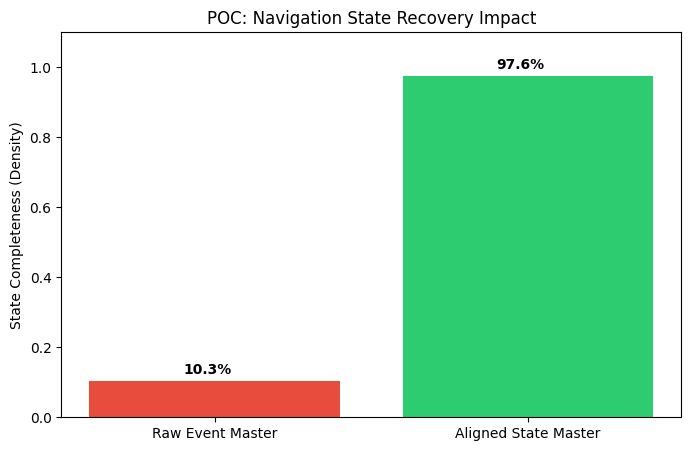

In [8]:
import matplotlib.pyplot as plt

labels = ['Raw Event Master', 'Aligned State Master']
densities = [report['event_density'][0], report['state_density'][0]]

plt.figure(figsize=(8, 5))
plt.bar(labels, densities, color=['#e74c3c', '#2ecc71'])
plt.ylabel('State Completeness (Density)')
plt.title('POC: Navigation State Recovery Impact')
plt.ylim(0, 1.1)

# Annotate percentages
for i, v in enumerate(densities):
    plt.text(i - 0.1, v + 0.02, f"{v:.1%}", fontweight='bold')

plt.show()

In [ ]:
con = duckdb.connect(db_path)

# Ensure the state is persisted as a table, not just a transient result
con.execute("DROP TABLE IF EXISTS fact_nav_state;")
con.execute("""
    CREATE TABLE fact_nav_state AS
    SELECT
        *,
        LAST_VALUE(RelHomeAlt IGNORE NULLS) OVER (
            ORDER BY mission_time ASC, inode ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as aligned_alt
    FROM fact_nav;
""")

print("✨ fact_nav_state finalized.")
con.close()

✨ fact_nav_state finalized.


In [ ]:
con = duckdb.connect(db_path)

# Force a physical table creation for the Gold Layer
con.execute("DROP TABLE IF EXISTS fact_nav_state;")
con.execute("""
    CREATE TABLE fact_nav_state AS
    SELECT
        *,
        -- Fill Home Alt Gaps
        LAST_VALUE(RelHomeAlt IGNORE NULLS) OVER (
            ORDER BY mission_time ASC, inode ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as aligned_alt,
        -- Fill Origin Alt Gaps (Required for Drift/Integrity Report)
        LAST_VALUE(RelOriginAlt IGNORE NULLS) OVER (
            ORDER BY mission_time ASC, inode ASC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) as aligned_origin
    FROM fact_nav;
""")

# CRITICAL: Verify it actually exists now
inventory = con.execute("SELECT table_name FROM duckdb_tables() WHERE table_name = 'fact_nav_state'").df()

if not inventory.empty:
    print("✅ SUCCESS: 'fact_nav_state' is now a physical Gold table.")
else:
    print("❌ ERROR: Table still not showing in inventory.")

con.close()

✅ SUCCESS: 'fact_nav_state' is now a physical Gold table.


In [ ]:
import duckdb
import os

def generate_mentor_reports(mission_id):
    home = os.path.expanduser("~")
    db_path = os.path.join(home, "ardupilot-nav-domain-poc/bin/vault/warehouse_df/drone_df_views.db")
    con = duckdb.connect(db_path)

    # 1. Recovery Metrics (The "Before vs After")
    recovery = con.execute(f"""
        SELECT
            '{mission_id}' as mission,
            round(COUNT(RelHomeAlt)::FLOAT / COUNT(*) * 100, 1) as silver_density_pct,
            round(COUNT(aligned_alt)::FLOAT / COUNT(*) * 100, 1) as gold_density_pct,
            COUNT(*) - COUNT(RelHomeAlt) as holes_plugged
        FROM fact_nav_state
        WHERE mission_id = '{mission_id}'
    """).df()

    # 2. Flight Integrity (The "Physics Check")
    # We use our new 'aligned_origin' column here!
    integrity = con.execute(f"""
        SELECT
            round(quantile_cont(abs(aligned_alt - aligned_origin), 0.95), 3) as p95_drift_m,
            round(max(abs(aligned_alt - aligned_origin)), 3) as peak_drift_m,
            round(avg(HDop), 2) as avg_signal_quality
        FROM fact_nav_state
        WHERE mission_id = '{mission_id}'
    """).df()

    con.close()
    return recovery, integrity

# --- Execute and Display ---
mission_id = "MISSION_1771663015"
recovery_df, integrity_df = generate_mentor_reports(mission_id)

print(f"📊 MENTOR REPORT: {mission_id}")
print("\n[REPORT A: DATA REFINERY PERFORMANCE]")
display(recovery_df)

print("\n[REPORT B: FLIGHT DOMAIN INTEGRITY]")
display(integrity_df)

📊 MENTOR REPORT: MISSION_1771663015

[REPORT A: DATA REFINERY PERFORMANCE]


,mission,silver_density_pct,gold_density_pct,holes_plugged
0,MISSION_1771663015,10.3,97.599998,21823



[REPORT B: FLIGHT DOMAIN INTEGRITY]


,p95_drift_m,peak_drift_m,avg_signal_quality
0,0.0,2.771,1.21
